# =====================================================================
# COHORT RETENTION ANALYSIS PIPELINE (Python / Jupyter Notebook)
# =====================================================================

## ---------------------------------------------------------------------
## CELL 1: Imports & Database Connection Setup
## ---------------------------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Database Connection Settings
DB_USER = "postgres"
DB_PASSWORD = "1234"  # Replace with your actual PostgreSQL password
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "postgres"            # Replace with your actual database name

# Create SQLAlchemy Engine
engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

## ---------------------------------------------------------------------
## CELL 2: Fetch & Pivot Cohort Retention Matrix (Q7)
## ---------------------------------------------------------------------

In [2]:
query_retention = """
WITH delivered_orders AS (
    SELECT o.order_id, c.customer_unique_id, o.order_purchase_timestamp
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),
customer_cohorts AS (
    SELECT customer_unique_id, DATE_TRUNC('month', MIN(order_purchase_timestamp)) AS cohort_month
    FROM delivered_orders GROUP BY customer_unique_id
),
customer_activities AS (
    SELECT DISTINCT customer_unique_id, DATE_TRUNC('month', order_purchase_timestamp) AS activity_month
    FROM delivered_orders
),
period_calc AS (
    SELECT 
        a.customer_unique_id,
        c.cohort_month,
        (EXTRACT(YEAR FROM a.activity_month) - EXTRACT(YEAR FROM c.cohort_month)) * 12 +
        (EXTRACT(MONTH FROM a.activity_month) - EXTRACT(MONTH FROM c.cohort_month)) AS period_number
    FROM customer_activities a JOIN customer_cohorts c ON a.customer_unique_id = c.customer_unique_id
),
cohort_sizes AS (
    SELECT cohort_month, COUNT(DISTINCT customer_unique_id) AS total_size
    FROM customer_cohorts GROUP BY cohort_month
),
retention_counts AS (
    SELECT cohort_month, period_number, COUNT(DISTINCT customer_unique_id) AS active_users
    FROM period_calc GROUP BY cohort_month, period_number
)
SELECT 
    TO_CHAR(rc.cohort_month, 'YYYY-MM') AS cohort_month,
    rc.period_number,
    ROUND((rc.active_users::NUMERIC / cs.total_size::NUMERIC) * 100, 2) AS retention_rate_pct
FROM retention_counts rc
JOIN cohort_sizes cs ON rc.cohort_month = cs.cohort_month
ORDER BY rc.cohort_month, rc.period_number;
"""

df_retention = pd.read_sql_query(query_retention, engine)

# Pivot table to form the 2D Retention Matrix (Cohort Month vs Period Number)
retention_matrix = df_retention.pivot(
    index='cohort_month', 
    columns='period_number', 
    values='retention_rate_pct'
)

# Display matrix head
print("Retention Matrix Preview:")
retention_matrix.head()

Retention Matrix Preview:


period_number,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN


## ---------------------------------------------------------------------
## CELL 3: Generate Cohort Retention Heatmap
## ---------------------------------------------------------------------

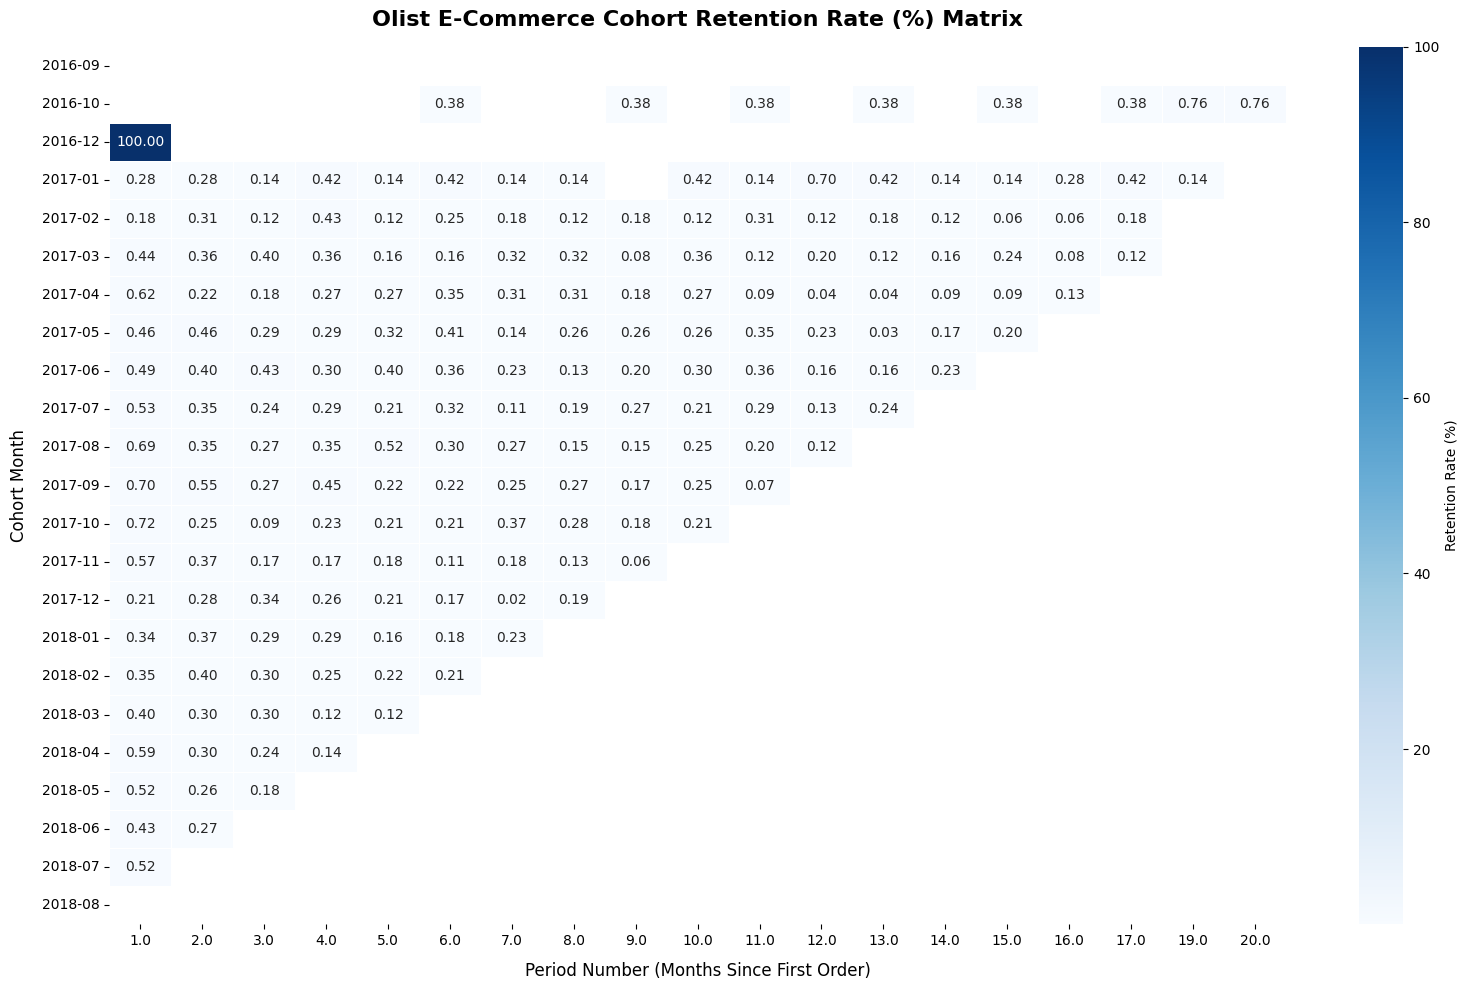

In [3]:
plt.figure(figsize=(16, 10))

# Mask Period 0 (always 100%) to focus on repeat behavior contrast across periods 1+
plot_data = retention_matrix.iloc[:, 1:]

sns.heatmap(
    plot_data, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5
)

plt.title("Olist E-Commerce Cohort Retention Rate (%) Matrix", fontsize=16, pad=15, fontweight='bold')
plt.xlabel("Period Number (Months Since First Order)", fontsize=12, labelpad=10)
plt.ylabel("Cohort Month", fontsize=12, labelpad=10)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## ---------------------------------------------------------------------
## CELL 4: Plot Average Retention Decay Curve (Q8)
## ---------------------------------------------------------------------

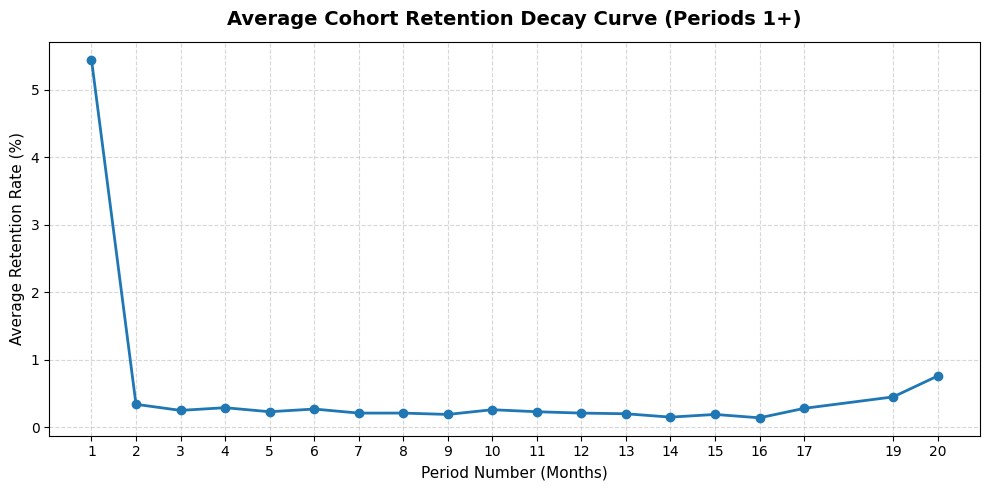

In [4]:
query_avg_retention = """
WITH delivered_orders AS (
    SELECT o.order_id, c.customer_unique_id, o.order_purchase_timestamp
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),
customer_cohorts AS (
    SELECT customer_unique_id, DATE_TRUNC('month', MIN(order_purchase_timestamp)) AS cohort_month
    FROM delivered_orders GROUP BY customer_unique_id
),
customer_activities AS (
    SELECT DISTINCT customer_unique_id, DATE_TRUNC('month', order_purchase_timestamp) AS activity_month
    FROM delivered_orders
),
period_calc AS (
    SELECT 
        a.customer_unique_id,
        c.cohort_month,
        (EXTRACT(YEAR FROM a.activity_month) - EXTRACT(YEAR FROM c.cohort_month)) * 12 +
        (EXTRACT(MONTH FROM a.activity_month) - EXTRACT(MONTH FROM c.cohort_month)) AS period_number
    FROM customer_activities a JOIN customer_cohorts c ON a.customer_unique_id = c.customer_unique_id
),
cohort_sizes AS (
    SELECT cohort_month, COUNT(DISTINCT customer_unique_id) AS total_size
    FROM customer_cohorts GROUP BY cohort_month
),
retention_rates AS (
    SELECT 
        p.cohort_month,
        p.period_number,
        (COUNT(DISTINCT p.customer_unique_id)::NUMERIC / cs.total_size::NUMERIC) * 100 AS retention_rate
    FROM period_calc p
    JOIN cohort_sizes cs ON p.cohort_month = cs.cohort_month
    GROUP BY p.cohort_month, p.period_number, cs.total_size
)
SELECT 
    period_number,
    ROUND(AVG(retention_rate), 2) AS avg_retention_pct
FROM retention_rates
GROUP BY period_number
ORDER BY period_number;
"""

df_avg = pd.read_sql_query(query_avg_retention, engine)

# Filter out Period 0 for clear scale inspection of repeat behavior
df_avg_repeat = df_avg[df_avg['period_number'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df_avg_repeat['period_number'], df_avg_repeat['avg_retention_pct'], marker='o', linewidth=2, color='#1f77b4')

plt.title("Average Cohort Retention Decay Curve (Periods 1+)", fontsize=14, pad=12, fontweight='bold')
plt.xlabel("Period Number (Months)", fontsize=11)
plt.ylabel("Average Retention Rate (%)", fontsize=11)
plt.xticks(df_avg_repeat['period_number'])
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## ---------------------------------------------------------------------
## CELL 5: Fetch Revenue Retention per Cohort (Q10)
## ---------------------------------------------------------------------

In [5]:
query_revenue = """
WITH delivered_orders AS (
    SELECT o.order_id, c.customer_unique_id, o.order_purchase_timestamp
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),
customer_cohorts AS (
    SELECT customer_unique_id, DATE_TRUNC('month', MIN(order_purchase_timestamp)) AS cohort_month
    FROM delivered_orders GROUP BY customer_unique_id
),
order_revenues AS (
    SELECT 
        o.order_id,
        c.customer_unique_id,
        DATE_TRUNC('month', o.order_purchase_timestamp) AS activity_month,
        SUM(i.price) AS total_order_revenue
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_items i ON o.order_id = i.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.order_id, c.customer_unique_id, activity_month
)
SELECT 
    TO_CHAR(cc.cohort_month, 'YYYY-MM') AS cohort_month,
    (EXTRACT(YEAR FROM r.activity_month) - EXTRACT(YEAR FROM cc.cohort_month)) * 12 +
    (EXTRACT(MONTH FROM r.activity_month) - EXTRACT(MONTH FROM cc.cohort_month)) AS period_number,
    ROUND(SUM(r.total_order_revenue), 2) AS period_revenue
FROM order_revenues r
JOIN customer_cohorts cc ON r.customer_unique_id = cc.customer_unique_id
GROUP BY cohort_month, period_number
ORDER BY cohort_month, period_number;
"""

df_revenue = pd.read_sql_query(query_revenue, engine)

revenue_matrix = df_revenue.pivot(
    index='cohort_month', 
    columns='period_number', 
    values='period_revenue'
).fillna(0)

print("Revenue Matrix Preview ($):")
revenue_matrix.head()

Revenue Matrix Preview ($):


period_number,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,134.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00
2016-10,40325.11,0.00,0.00,0.00,0.00,0.00,99.99,0.00,0.0,339.00,0.0,49.00,0.00,115.2,0.0,298.6,0.0,98.00,289.28,158.39
2016-12,10.90,10.90,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00
2017-01,111787.46,76.12,82.89,75.00,199.70,59.99,372.95,79.80,25.9,0.00,373.1,49.00,456.14,298.8,48.0,89.9,163.9,319.79,38.00,0.00
2017-02,234147.28,434.90,484.50,89.25,978.22,49.99,583.89,234.89,432.8,285.76,318.9,382.78,247.00,279.8,143.8,117.0,251.8,325.90,0.00,0.00
